In [278]:
# !pip install --upgrade pandas-profiling
# !pip install ydata_profiling


In [370]:
# library for feature engineering and EDA
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image
from datetime import datetime
import random

# library for statistic
from scipy import stats
from scipy.stats import skew
from scipy.stats import kurtosis

# library for machine learning
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

%matplotlib inline

In [280]:
import ydata_profiling

In [281]:
df = pd.read_csv('data/data.csv', encoding='unicode_escape')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [282]:
print("Duplicated numbers : ", len(df[df.duplicated()]))

Duplicated numbers :  5268


In [283]:
df = df.drop_duplicates().reset_index(drop=True)

In [284]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536641 entries, 0 to 536640
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.8+ MB


In [285]:
# categorical and numeric columns
for column_name in list(df.columns):
    print(column_name, df[column_name].dtype, df[column_name].unique())

InvoiceNo object ['536365' '536366' '536367' ... '581585' '581586' '581587']
StockCode object ['85123A' '71053' '84406B' ... '90214U' '47591b' '23843']
Description object ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' ... 'lost'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']
Quantity int64 [     6      8      2     32      3      4     24     12     48     18
     20     36     80     64     10    120     96     23      5      1
     -1     50     40    100    192    432    144    288    -12    -24
     16      9    128     25     30     28      7     56     72    200
    600    480     -6     14     -2     11     33     13     -4     -5
     -7     -3     70    252     60    216    384    -10     27     15
     22     19     17     21     34     47    108     52  -9360    -38
     75    270     42    240     90    320   1824    204     69    -36
   -192   -144    160   2880   1400     39    -48    -50     26   1440
 

In [286]:
list_cast_to_object = ["CustomerID"]
for column_name in list_cast_to_object:
  df[column_name] = df[column_name].astype(object)

In [287]:
list_categorical_columns = list(df.select_dtypes(include=['object']).columns)
list_numeric_columns = list(df.select_dtypes(include=['float64','int64']).columns)
print(len(df))
print(len(df.columns))
print(len(list_categorical_columns))
print(len(list_numeric_columns))

536641
8
6
2


In [288]:
list_numeric_columns

['Quantity', 'UnitPrice']

In [289]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [290]:
df[list_categorical_columns].nunique().sort_values() 
# 불필요한 컬럼 보이지 않음

Country           38
StockCode       4070
Description     4223
CustomerID      4372
InvoiceDate    23260
InvoiceNo      25900
dtype: int64

In [291]:
df = df.drop(["Description"], axis=1)
list_categorical_columns.remove("Description")

In [292]:
list_categorical_columns

['InvoiceNo', 'StockCode', 'InvoiceDate', 'CustomerID', 'Country']

<Axes: xlabel='StockCode', ylabel='Count'>

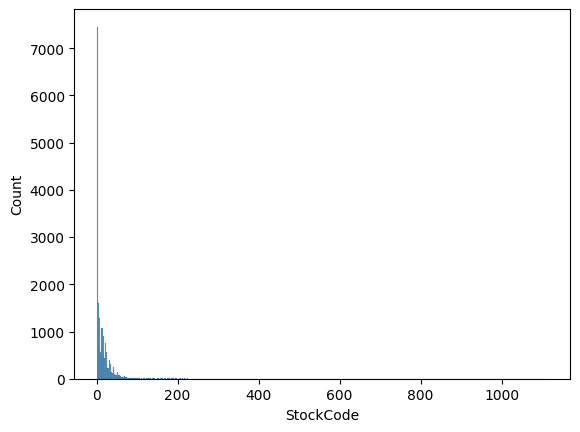

In [293]:
df_invoiceno_count = df.groupby("InvoiceNo").count()["StockCode"]
sns.histplot(df_invoiceno_count)

In [294]:
df_invoiceno_count.describe()

# max값을 한 번 확인해보자. 

count    25900.000000
mean        20.719730
std         42.793088
min          1.000000
25%          2.000000
50%         10.000000
75%         23.000000
max       1114.000000
Name: StockCode, dtype: float64

In [295]:
no_invoice_max = df_invoiceno_count[df_invoiceno_count == 1114]
print(no_invoice_max.index[0])
df[df.InvoiceNo == no_invoice_max.index[0]]

# 해당 count(1114, max)를 갖는 invoice의 CustomerID가 NaN으로 처리해줘야할 필요성이 있음 

573585


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
426616,573585,11001,2,10/31/2011 14:41,3.29,NaN,United Kingdom
426617,573585,15036,15,10/31/2011 14:41,1.63,NaN,United Kingdom
426618,573585,15039,15,10/31/2011 14:41,1.63,NaN,United Kingdom
426619,573585,15056BL,1,10/31/2011 14:41,12.46,NaN,United Kingdom
426620,573585,15056N,1,10/31/2011 14:41,12.46,NaN,United Kingdom
...,...,...,...,...,...,...,...
427725,573585,90209C,3,10/31/2011 14:41,2.07,NaN,United Kingdom
427726,573585,90214S,1,10/31/2011 14:41,0.83,NaN,United Kingdom
427727,573585,DOT,1,10/31/2011 14:41,2019.05,NaN,United Kingdom
427728,573585,gift_0001_20,1,10/31/2011 14:41,16.67,NaN,United Kingdom


In [296]:
df = df.dropna().reset_index(drop=True)

<Axes: ylabel='StockCode'>

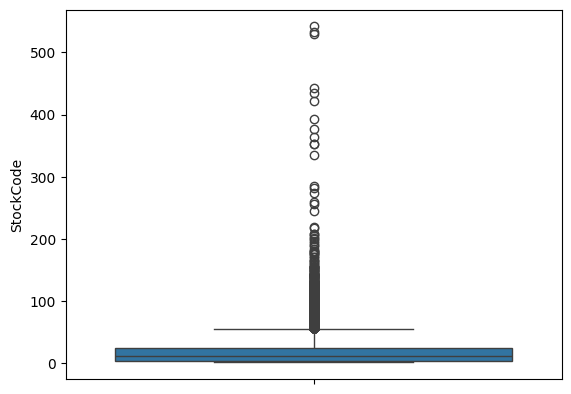

In [297]:
df_invoiceno_count = df.groupby("InvoiceNo").count()["StockCode"]
sns.boxplot(df_invoiceno_count)

In [298]:
df_invoiceno_count.describe()

count    22190.000000
mean        18.098423
std         23.363888
min          1.000000
25%          3.000000
50%         12.000000
75%         24.000000
max        542.000000
Name: StockCode, dtype: float64

In [299]:
# max값을 다시 한 번 더 확인 
no_invoice_max = df_invoiceno_count[df_invoiceno_count == 542]
print(no_invoice_max.index[0])
df[df.InvoiceNo == no_invoice_max.index[0]]


576339


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
347900,576339,10135,14,11/14/2011 15:27,2.46,14096.0,United Kingdom
347901,576339,15044A,1,11/14/2011 15:27,5.79,14096.0,United Kingdom
347902,576339,16238,2,11/14/2011 15:27,0.42,14096.0,United Kingdom
347903,576339,16258A,1,11/14/2011 15:27,0.83,14096.0,United Kingdom
347904,576339,17003,2,11/14/2011 15:27,0.63,14096.0,United Kingdom
...,...,...,...,...,...,...,...
348437,576339,90083,1,11/14/2011 15:27,1.63,14096.0,United Kingdom
348438,576339,90086,1,11/14/2011 15:27,1.63,14096.0,United Kingdom
348439,576339,90119,11,11/14/2011 15:27,2.46,14096.0,United Kingdom
348440,576339,90166,1,11/14/2011 15:27,4.15,14096.0,United Kingdom


In [300]:
# 2. 상품별로 얼마나 구매를 많이 하는지? 
df.StockCode.nunique()

3684

In [301]:
no_stockcode_buy = df.groupby("StockCode").count()["InvoiceNo"]

In [302]:
no_stockcode_buy.sort_values(ascending=False)
#no_stockcode_buy

StockCode
85123A    2065
22423     1894
85099B    1659
47566     1409
84879     1405
          ... 
90176B       1
90176C       1
90069        1
90035C       1
37461        1
Name: InvoiceNo, Length: 3684, dtype: int64

In [303]:
no_stockcode_buy.describe()

count    3684.000000
mean      109.013029
std       165.656870
min         1.000000
25%        12.000000
50%        48.000000
75%       137.000000
max      2065.000000
Name: InvoiceNo, dtype: float64

In [304]:
df["InvoiceDate"] = pd.to_datetime(df.InvoiceDate)

In [305]:
df_tmp = df
df_tmp

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
401599,581587,22613,12,2011-12-09 12:50:00,0.85,12680.0,France
401600,581587,22899,6,2011-12-09 12:50:00,2.10,12680.0,France
401601,581587,23254,4,2011-12-09 12:50:00,4.15,12680.0,France
401602,581587,23255,4,2011-12-09 12:50:00,4.15,12680.0,France


In [306]:
df_tmp["weekday"] = df.InvoiceDate.dt.weekday
df_tmp["month"] = df.InvoiceDate.dt.month
df_tmp["hour"] = df.InvoiceDate.dt.hour

In [307]:
df_tmp.head(2)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,weekday,month,hour
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2,12,8
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2,12,8


<Axes: xlabel='weekday'>

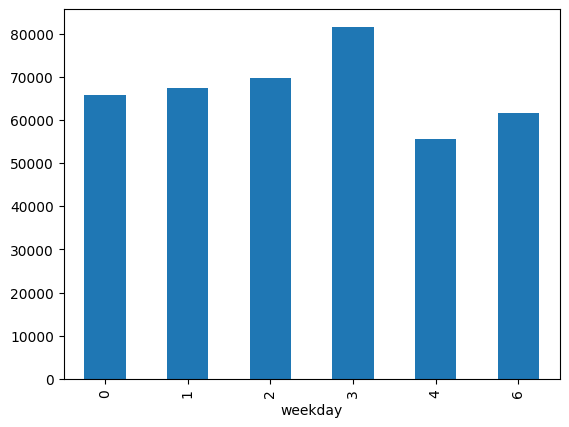

In [308]:
df_tmp.groupby("weekday").count()["Quantity"].plot.bar()

<Axes: xlabel='month'>

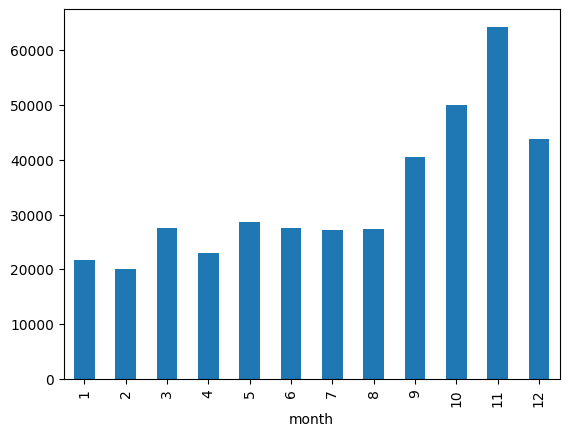

In [309]:
df_tmp.groupby("month").count()["Quantity"].plot.bar()

<Axes: xlabel='hour'>

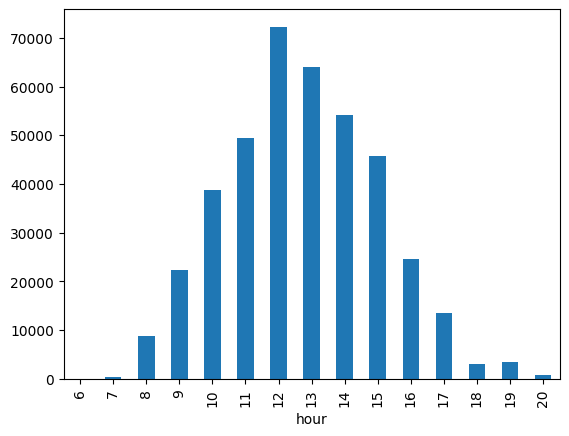

In [310]:
df_tmp.groupby("hour").count()["Quantity"].plot.bar()

In [311]:
del df_tmp

In [312]:
df.Country.nunique()

37

<Axes: xlabel='Country'>

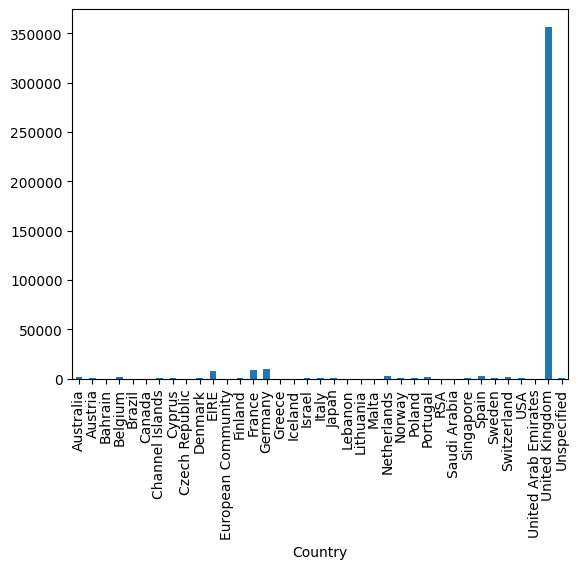

In [313]:
df.groupby("Country").count()["Quantity"].plot.bar()

Numeric Data Analysis

In [314]:
df[list_numeric_columns].nunique().sort_values()

Quantity     436
UnitPrice    620
dtype: int64

In [315]:
df[list_numeric_columns].describe()

,Quantity,UnitPrice
count,401604.000000,401604.000000
mean,12.183273,3.474064
std,250.283037,69.764035
min,-80995.000000,0.000000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,38970.000000


In [316]:
df[df.Quantity < 0 ]
# 환불 데이터로 확인됨

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,weekday,month,hour
141,C536379,D,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,2,12,9
154,C536383,35004C,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,2,12,9
235,C536391,22556,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,2,12,10
236,C536391,21984,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,2,12,10
237,C536391,21983,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,2,12,10
...,...,...,...,...,...,...,...,...,...,...
401159,C581490,23144,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,4,12,9
401243,C581499,M,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,4,12,10
401410,C581568,21258,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,4,12,11
401411,C581569,84978,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,4,12,11


In [317]:
# 환불하지 않은 데이터만 활용
df = df[df.Quantity > 0]

In [318]:
df[list_numeric_columns].describe()

,Quantity,UnitPrice
count,392732.000000,392732.000000
mean,13.153718,3.125596
std,181.588420,22.240725
min,1.000000,0.000000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


<Axes: ylabel='Quantity'>

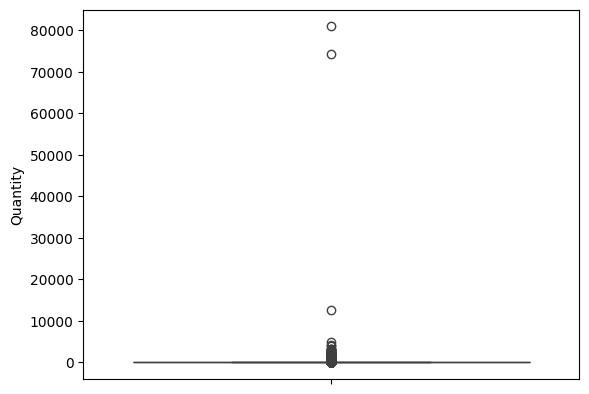

In [319]:
sns.boxplot(df["Quantity"])

# 너무 큰 이상치는 제거하기로 결정.
# 기준은 각 자 판단하여 정하는것. 본 실습에서는 10000개 초과인 경우는 제외

In [320]:
# filter, 10000개 이하 구매건만 
df = df[df.Quantity < 10000]

<Axes: ylabel='Quantity'>

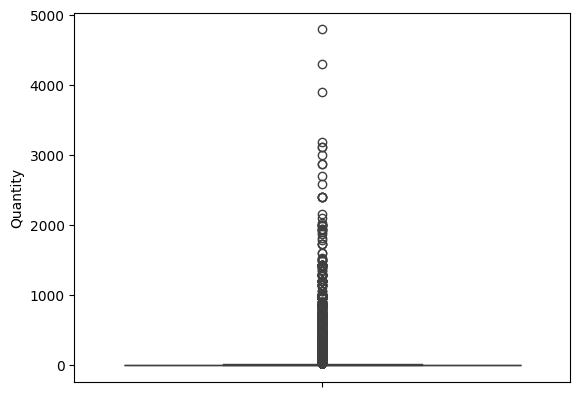

In [321]:
sns.boxplot(df["Quantity"])

<Axes: ylabel='UnitPrice'>

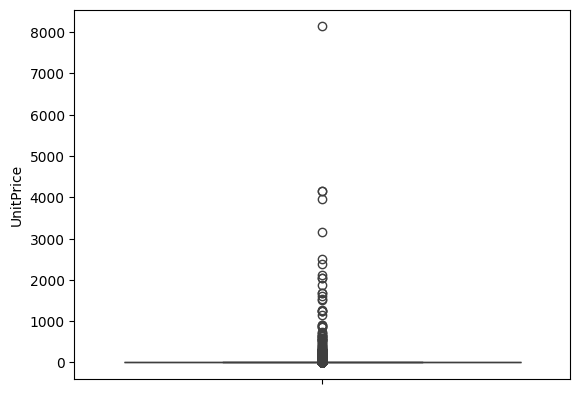

In [322]:
sns.boxplot(df["UnitPrice"])

In [323]:
# df.profile_report().to_file("data/data_eda_with_pandasprofiling.html")

In [324]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
weekday        0
month          0
hour           0
dtype: int64

In [325]:
df.head(1)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,weekday,month,hour
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2,12,8


In [326]:
# Recency Feature
df_customer_last_date = df.groupby("CustomerID").agg(max)["InvoiceDate"].reset_index()
df_customer_last_date.head(2)

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_5024\2036527822.py:2: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df_customer_last_date = df.groupby("CustomerID").agg(max)["InvoiceDate"].reset_index()


,CustomerID,InvoiceDate
0,12347.0,2011-12-07 15:52:00
1,12348.0,2011-09-25 13:13:00


In [328]:
df_recency = df_customer_last_date.drop(columns=["InvoiceDate"])
df_recency.head(3)

,CustomerID,recency
0,12347.0,-2
1,12348.0,-75
2,12349.0,-19


In [329]:
# Frequency Feature
df_frequency = df[["CustomerID", "InvoiceNo"]].drop_duplicates().groupby("CustomerID").count().reset_index()
df_frequency.rename(columns = {'InvoiceNo':'frequency'}, inplace = True)
df_frequency.head(3)

,CustomerID,frequency
0,12347.0,7
1,12348.0,4
2,12349.0,1


In [350]:
df["monetary_row"] = df["Quantity"] * df["UnitPrice"]
# df_monetary = df.groupby("CustomerID").agg(sum)["monetary_row"].reset_index() --> Makes an error.
df_monetary = df.groupby("CustomerID")["monetary_row"].sum().reset_index()
df_monetary.rename(columns = {'monetary_row':'monetary'}, inplace = True)
df_monetary.head(3)

,CustomerID,monetary
0,12347.0,4310.00
1,12348.0,1797.24
2,12349.0,1757.55


In [351]:
df_rfm = df_recency.merge(df_frequency, on="CustomerID").merge(df_monetary, on="CustomerID")


In [352]:
df_rfm.head(3)

,CustomerID,recency,frequency,monetary
0,12347.0,-2,7,4310.00
1,12348.0,-75,4,1797.24
2,12349.0,-19,1,1757.55


In [353]:
# RFM Score 
df_rfm["recency_ntile"] = pd.qcut(df_rfm["recency"],5, labels=[1,2,3,4,5])
df_rfm["frequency_ntile"] = pd.qcut(df_rfm["frequency"].rank(method='first'), 5, labels=[1,2,3,4,5])
df_rfm["monetary_ntile"] = pd.qcut(df_rfm["monetary"],5, labels=[1,2,3,4,5])

In [354]:
df_rfm.head(5)

,CustomerID,recency,frequency,monetary,recency_ntile,frequency_ntile,monetary_ntile
0,12347.0,-2,7,4310.00,5,5,5
1,12348.0,-75,4,1797.24,2,4,4
2,12349.0,-19,1,1757.55,4,1,4
3,12350.0,-310,1,334.40,1,1,2
4,12352.0,-36,8,2506.04,3,5,5


In [355]:
# kmeans clustering 을 위한 feature  
df_rfm_clustering = df_rfm.copy()

In [356]:
df_rfm_clustering = df_rfm_clustering[["CustomerID","recency", "frequency", "monetary"]]
df_rfm_clustering.head(2)

,CustomerID,recency,frequency,monetary
0,12347.0,-2,7,4310.00
1,12348.0,-75,4,1797.24


In [357]:
scaler = MinMaxScaler()
list_scaling = ["recency", "frequency", "monetary"]
df_rfm_clustering.loc[:, list_scaling] = scaler.fit_transform(df_rfm_clustering[list_scaling])
df_rfm_clustering.head(2)

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_5024\3649173958.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.99465241 0.79946524 0.94919786 ... 0.97860963 0.98930481 0.88502674]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_rfm_clustering.loc[:, list_scaling] = scaler.fit_transform(df_rfm_clustering[list_scaling])
C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_5024\3649173958.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.02870813 0.01435407 0.         ... 0.00478469 0.07177033 0.00956938]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_rfm_clustering.loc[:, list_scaling] = scaler.fit_transform(df_rfm_clustering[list_scaling])


,CustomerID,recency,frequency,monetary
0,12347.0,0.994652,0.028708,0.015371
1,12348.0,0.799465,0.014354,0.006404


In [358]:
df_heuristic_rfm =df_rfm.groupby(["recency_ntile","monetary_ntile","frequency_ntile"]).agg(np.mean).reset_index()
df_heuristic_rfm

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_5024\3723777536.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_heuristic_rfm =df_rfm.groupby(["recency_ntile","monetary_ntile","frequency_ntile"]).agg(np.mean).reset_index()
C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_5024\3723777536.py:1: FutureWarning: The provided callable <function mean at 0x0000025D70559260> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_heuristic_rfm =df_rfm.groupby(["recency_ntile","monetary_ntile","frequency_ntile"]).agg(np.mean).reset_index()


,recency_ntile,monetary_ntile,frequency_ntile,CustomerID,recency,frequency,monetary
0,1,1,1,14129.610811,-285.291892,1.000000,144.089135
1,1,1,2,17022.155844,-273.428571,1.032468,147.116688
2,1,1,3,16353.809524,-237.238095,2.000000,161.810000
3,1,1,4,16922.666667,-211.666667,3.000000,208.880000
4,1,1,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
120,5,5,1,15195.000000,-3.000000,1.000000,3861.000000
121,5,5,2,13868.000000,-7.000000,2.000000,3192.540000
122,5,5,3,13943.800000,-8.600000,2.800000,3508.084000
123,5,5,4,14383.317073,-7.024390,4.390244,3293.502927


In [359]:
# VIP 고객에게 Marketing 진행
# recency_ntile == 5, monetary_ntile == 5, frequency_ntile == 5
df_rfm[(df_rfm.recency_ntile == 5) & (df_rfm.monetary_ntile == 5) & (df_rfm.frequency_ntile == 5)]

,CustomerID,recency,frequency,monetary,recency_ntile,frequency_ntile,monetary_ntile
0,12347.0,-2,7,4310.00,5,5,5
14,12362.0,-3,10,5226.23,5,5,5
55,12417.0,-3,9,3649.10,5,5,5
70,12433.0,-1,7,13375.87,5,5,5
74,12437.0,-2,18,4951.41,5,5,5
...,...,...,...,...,...,...,...
4296,18229.0,-12,20,7276.90,5,5,5
4297,18230.0,-9,7,2810.20,5,5,5
4306,18241.0,-10,17,2073.09,5,5,5
4308,18245.0,-7,7,2567.06,5,5,5


In [360]:
# 이전에는 구매를 많이 했지만, 최근들어 구매 이력이 없는 고객에게 마케팅
# recency_ntile == 1, monetary_ntile == 5, frequency_ntile == 5

df_rfm[(df_rfm.recency_ntile == 1) & (df_rfm.monetary_ntile == 5) & (df_rfm.frequency_ntile == 5)]

,CustomerID,recency,frequency,monetary,recency_ntile,frequency_ntile,monetary_ntile
565,13093.0,-276,8,7832.47,1,5,5
2117,15235.0,-218,12,2247.51,1,5,5
3569,17230.0,-264,8,3638.41,1,5,5
3763,17504.0,-206,9,2997.03,1,5,5
4015,17850.0,-372,34,5391.21,1,5,5


In [361]:
# 구매율과 매출이 높은 고객이지만, 1~2달 동안 구매가 없던 고객들에게 쿠폰 지급
# recency_ntile == 3, monetary_ntile == 5, frequency_ntile == 5

df_rfm[(df_rfm.recency_ntile == 3) & (df_rfm.monetary_ntile >= 5) & (df_rfm.frequency_ntile >= 5)]

,CustomerID,recency,frequency,monetary,recency_ntile,frequency_ntile,monetary_ntile
4,12352.0,-36,8,2506.04,3,5,5
68,12431.0,-36,15,6419.95,3,5,5
91,12457.0,-66,7,2363.23,3,5,5
199,12594.0,-38,10,3338.22,3,5,5
234,12637.0,-67,8,6002.90,3,5,5
...,...,...,...,...,...,...,...
4086,17940.0,-49,10,4020.04,3,5,5
4104,17965.0,-38,14,2599.19,3,5,5
4134,18008.0,-70,9,2116.19,3,5,5
4293,18226.0,-44,11,5228.05,3,5,5


In [362]:
df_rfm_clustering

,CustomerID,recency,frequency,monetary
0,12347.0,0.994652,0.028708,0.015371
1,12348.0,0.799465,0.014354,0.006404
2,12349.0,0.949198,0.000000,0.006262
3,12350.0,0.171123,0.000000,0.001183
4,12352.0,0.903743,0.033493,0.008933
...,...,...,...,...
4332,18280.0,0.256684,0.000000,0.000634
4333,18281.0,0.516043,0.000000,0.000278
4334,18282.0,0.978610,0.004785,0.000625
4335,18283.0,0.989305,0.071770,0.007290


In [363]:
sum_of_squared_distances = []
K = range(2,20)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(df_rfm_clustering.drop("CustomerID", axis=1))
    sum_of_squared_distances.append(km.inertia_)

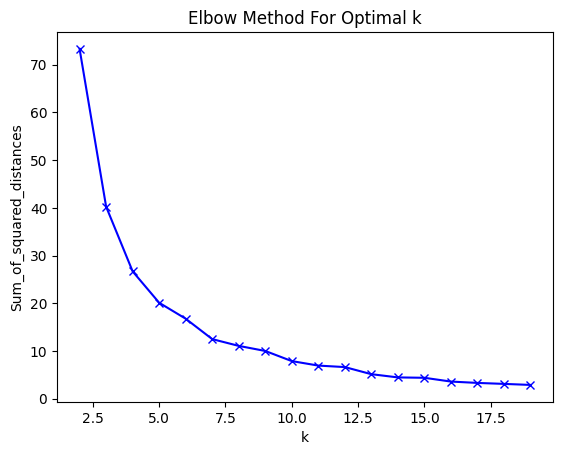

In [364]:
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [365]:
km_final = KMeans(n_clusters=5)
km_final = km_final.fit(df_rfm_clustering.drop("CustomerID", axis=1))

In [366]:
df_rfm_clustering["cluster_number"] = km_final.predict(df_rfm_clustering.drop("CustomerID", axis=1))

In [367]:
df_rfm_clustering

,CustomerID,recency,frequency,monetary,cluster_number
0,12347.0,0.994652,0.028708,0.015371,4
1,12348.0,0.799465,0.014354,0.006404,2
2,12349.0,0.949198,0.000000,0.006262,4
3,12350.0,0.171123,0.000000,0.001183,1
4,12352.0,0.903743,0.033493,0.008933,4
...,...,...,...,...,...
4332,18280.0,0.256684,0.000000,0.000634,3
4333,18281.0,0.516043,0.000000,0.000278,0
4334,18282.0,0.978610,0.004785,0.000625,4
4335,18283.0,0.989305,0.071770,0.007290,4


In [368]:
# cluster별 RFM score 패턴을 확인
cluster_result = df_rfm_clustering.drop(columns=["CustomerID"]).groupby("cluster_number").agg(np.mean)

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_5024\104636641.py:2: FutureWarning: The provided callable <function mean at 0x0000025D70559260> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  cluster_result = df_rfm_clustering.drop(columns=["CustomerID"]).groupby("cluster_number").agg(np.mean)


In [369]:
cluster_result

,recency,frequency,monetary
cluster_number,,,
0,0.592356,0.005635,0.002812
1,0.110886,0.001646,0.001373
2,0.813689,0.008162,0.003764
3,0.355767,0.002413,0.002131
4,0.953375,0.027450,0.012009
